In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [2]:
#Multiple mice
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_cxta_fc.pkl', 'rb') as file:
    collection_cxta_fc = pickle.load(file)

with open('/Users/suthardr/Desktop/collection_cxtb_fc.pkl', 'rb') as file:
    collection_cxtb_fc = pickle.load(file)


#Repeat for CxtA and B groups

In [3]:
#Save each mouse individually
m3 = stats.zscore(collection_cxta_fc.animals['astro3'].accepted_traces.to_numpy()[:3303,:], axis=0)
m4 = stats.zscore(collection_cxta_fc.animals['astro4'].accepted_traces.to_numpy()[:3303,:], axis=0)
m5 = stats.zscore(collection_cxta_fc.animals['astro5'].accepted_traces.to_numpy()[:3303,:], axis=0)
m6 = stats.zscore(collection_cxta_fc.animals['astro6'].accepted_traces.to_numpy()[:3303,:], axis=0)
m7 = stats.zscore(collection_cxtb_fc.animals['astro7'].accepted_traces.to_numpy()[:3303,:], axis=0)
m8 = stats.zscore(collection_cxtb_fc.animals['astro8'].accepted_traces.to_numpy()[:3303,:], axis=0)
m9 = stats.zscore(collection_cxtb_fc.animals['astro9'].accepted_traces.to_numpy()[:3303,:], axis=0)

In [4]:
fcA_array = np.hstack([m3, m4, m5, m9])
fcB_array = np.hstack([m6, m7, m8])

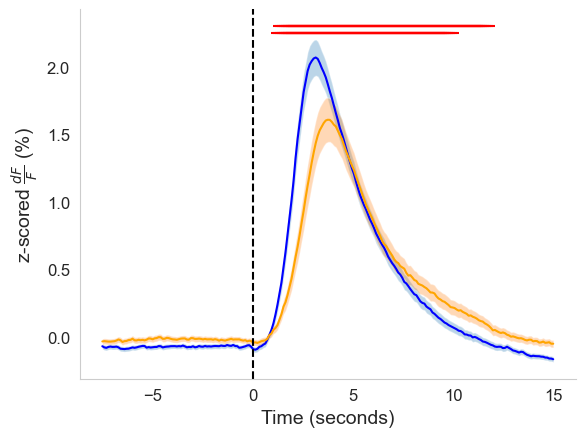

In [5]:
def shock_eta_all(data, timestamps, events=None, window=15, ci='tci', sig_duration=8, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 10)

    def event_interpolation(data, events_):
        interp = scipy.interpolate.interp1d(timestamps, data, kind='cubic')
        within_eta_ = np.zeros((len(events_), number_of_indices))
        for i, event in enumerate(events_):
            time_period = np.linspace(event - (window / 2), event + window, number_of_indices)
            within_eta_[i] = interp(time_period)
        return np.average(within_eta_, axis=0)

    across_eta_ = np.zeros((len(data), number_of_indices))

    # If there's only one event, repeat it for each curve
    if len(events) == 1:
        events = events * len(data)

    for j, curve in enumerate(data):
        across_eta_[j] = event_interpolation(curve, events[j])

    average_trace = np.average(across_eta_, axis=0)

    # choose t-confidence interval or bootstrapped
    if ci == 'tci':
        c_int = onep.tci(across_eta_)
    elif ci == 'bci':
        c_int = onep.bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    # find significant indices
    start_indices = onep.eta_significance(c_int[0, :], sig_duration=10)  # change to be dependent on the sampling rate

    # make a figure
    if ax is None:
        fig, ax = plt.subplots()
    time = np.linspace(-window / 2, window, number_of_indices)
    ax.plot(time, average_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # plot the significant deflections
    y_height = ax.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        ax.hlines(y=y_height, xmin=time[start_index], xmax=time[end_index], colors='r')

    if ax is None:
        return fig, ax, across_eta_
    else:
        return ax, across_eta_


# Create a figure and axis object
fig, ax = plt.subplots()

# Plot shock_eta_all for fcA_array
plot_A = shock_eta_all(
    data=fcA_array.T,
    timestamps=collection_cxta_fc.animals['astro4'].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300]],  # actually onsets
    window=15,
    ax=ax, color='blue'  # Pass the same axis object
)

# Plot shock_eta_all for fcB_array
plot_B = shock_eta_all(
    data=fcB_array.T,
    timestamps=collection_cxtb_fc.animals['astro7'].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300]],  # actually onsets
    window=15,
    ax=ax, color='orange'  # Pass the same axis object
)

# Customize axis and plot settings
sns.set_style("ticks")
ax.axvline(x=0, color='black', linestyle='--')
ax.set_xlabel('Time (seconds)', fontsize=14)
ax.set_ylabel(r'z-scored $\frac{dF}{F}$ (%)', fontsize=14)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(axis='both', which='major', labelsize=12)

# Show the plot
plt.show()